grid: nx=51, dt=1.60e-04, r=0.4, steps=1250
final time t=0.2000
max |FD - exact| at final time: 1.263e-04
saved: heat_snapshots.png, heat_heatmap.png


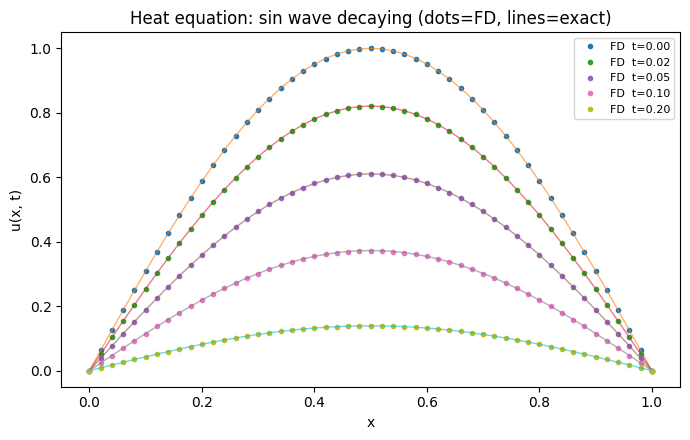

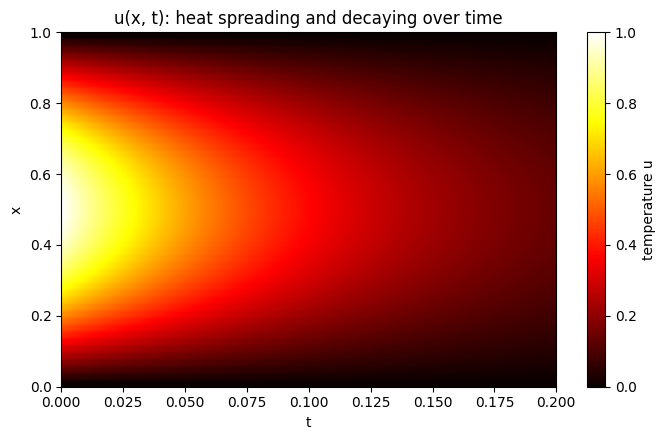

In [7]:
"""
1D Heat Equation baseline (no PINN).

    du/dt = alpha * d2u/dx2,   x in [0, 1],  t >= 0
    IC:  u(x, 0) = sin(pi x)
    BC:  u(0, t) = u(1, t) = 0

Exact solution:
    u(x, t) = sin(pi x) * exp(-alpha * pi^2 * t)

This script:
  1. Solves the PDE with an explicit finite-difference (FTCS) scheme.
  2. Compares against the exact solution and prints the max error.
  3. Saves two figures: snapshots over time, and a space-time heatmap.

The point: watch the initial sin wave keep its shape while decaying
exponentially. That "shape is fixed, amplitude decays" behavior is the
thing a PINN also has to discover.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---- parameters ----
alpha = 1.0          # thermal diffusivity
L = 1.0              # domain length
T = 0.2              # final time
nx = 51             # spatial grid points
dx = L / (nx - 1)

# Explicit FTCS is stable only if r = alpha*dt/dx^2 <= 0.5.
# Pick dt to satisfy that with margin.
r = 0.4
dt = r * dx**2 / alpha
nt = int(T / dt)

x = np.linspace(0, L, nx)


def exact(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)


# ---- finite difference solve (FTCS) ----
u = np.sin(np.pi * x)          # initial condition
u[0] = u[-1] = 0.0             # boundary condition

snapshots = {0.0: u.copy()}
save_times = [0.02, 0.05, 0.1, 0.2]
save_idx = {t: int(round(t / dt)) for t in save_times}

U = np.zeros((nt + 1, nx))     # full space-time field for the heatmap
U[0] = u

for n in range(1, nt + 1):
    u_new = u.copy()
    # interior update: u_i += r * (u_{i+1} - 2 u_i + u_{i-1})
    u_new[1:-1] = u[1:-1] + r * (u[2:] - 2 * u[1:-1] + u[:-2])
    u_new[0] = u_new[-1] = 0.0
    u = u_new
    U[n] = u
    for t, idx in save_idx.items():
        if n == idx:
            snapshots[t] = u.copy()

# ---- error check against exact solution ----
t_final = nt * dt
max_err = np.max(np.abs(u - exact(x, t_final)))
print(f"grid: nx={nx}, dt={dt:.2e}, r={r}, steps={nt}")
print(f"final time t={t_final:.4f}")
print(f"max |FD - exact| at final time: {max_err:.3e}")

# ---- figure 1: snapshots ----
fig, ax = plt.subplots(figsize=(7, 4.5))
xf = np.linspace(0, L, 400)
for t in sorted(snapshots):
    ax.plot(x, snapshots[t], "o", ms=3, label=f"FD  t={t:.2f}")
    ax.plot(xf, exact(xf, t), "-", lw=1, alpha=0.6)
ax.set_xlabel("x")
ax.set_ylabel("u(x, t)")
ax.set_title("Heat equation: sin wave decaying (dots=FD, lines=exact)")
ax.legend(fontsize=8)
fig.tight_layout()
#fig.savefig("/mnt/user-data/outputs/heat_snapshots.png", dpi=130)

# ---- figure 2: space-time heatmap ----
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
im = ax2.imshow(
    U.T, origin="lower", aspect="auto",
    extent=[0, t_final, 0, L], cmap="hot",
)
ax2.set_xlabel("t")
ax2.set_ylabel("x")
ax2.set_title("u(x, t): heat spreading and decaying over time")
fig2.colorbar(im, ax=ax2, label="temperature u")
fig2.tight_layout()
#fig2.savefig("/mnt/user-data/outputs/heat_heatmap.png", dpi=130)

print("saved: heat_snapshots.png, heat_heatmap.png")

using device: mps


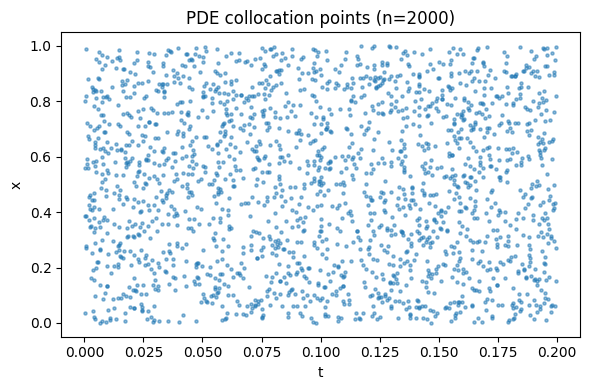

epoch     0  L_ic=8.16e-01  L_bc=6.78e-02  L_pde=1.14e-03  true_L2=4.78e-01
epoch   500  L_ic=1.22e-03  L_bc=2.73e-03  L_pde=2.98e-02  true_L2=1.97e-02
epoch  1000  L_ic=1.16e-05  L_bc=5.73e-05  L_pde=1.68e-03  true_L2=4.35e-03
epoch  1500  L_ic=7.15e-06  L_bc=2.59e-05  L_pde=5.48e-04  true_L2=1.62e-03
epoch  2000  L_ic=1.89e-06  L_bc=4.68e-06  L_pde=2.81e-04  true_L2=9.45e-04
epoch  2500  L_ic=1.00e-06  L_bc=4.19e-06  L_pde=2.28e-04  true_L2=6.52e-04
epoch  3000  L_ic=3.95e-04  L_bc=2.58e-04  L_pde=5.33e-04  true_L2=1.28e-02
epoch  3500  L_ic=5.68e-07  L_bc=1.56e-06  L_pde=1.71e-04  true_L2=6.45e-04
epoch  4000  L_ic=2.98e-05  L_bc=1.80e-05  L_pde=2.43e-04  true_L2=3.83e-03
epoch  4500  L_ic=3.53e-06  L_bc=5.63e-06  L_pde=1.10e-04  true_L2=1.82e-03
epoch  5000  L_ic=5.98e-06  L_bc=1.10e-05  L_pde=1.61e-04  true_L2=2.80e-03
saved: pinn_loss_curves.png, pinn_solution.png
final true L2 error: 2.795e-03


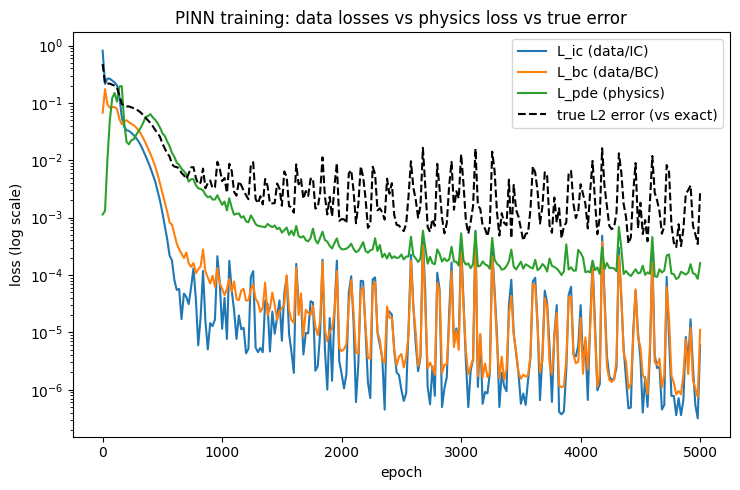

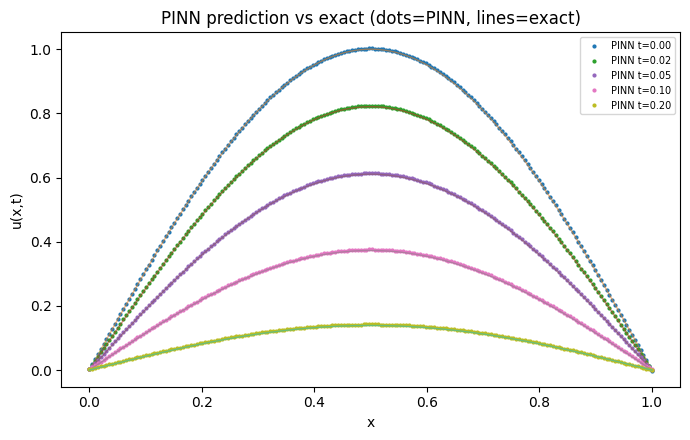

In [8]:
"""
PyTorch PINN baseline for the 1D heat equation.

    du/dt = alpha * d2u/dx2,   x in [0, 1],  t in [0, T]
    IC:  u(x, 0) = sin(pi x)
    BC:  u(0, t) = u(1, t) = 0
    Exact: u(x, t) = sin(pi x) * exp(-alpha * pi^2 * t)

Loss = w_ic * L_ic + w_bc * L_bc + w_pde * L_pde

We log L_ic, L_bc, L_pde separately every step, AND the true L2 error
against the exact solution (which the network never sees). The point
of separating these logs is to look for the "data-first, physics-later"
staged behavior: does L_ic/L_bc plateau early while L_pde keeps falling
later? That's the empirical question before bringing LLC into it.

The PINN model itself now lives in scripts/model/baseline01.py so it
can be reused outside this notebook.
"""

import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from scripts.model.baseline01 import PINN

torch.manual_seed(0)
np.random.seed(0)

#device = "cuda" if torch.cuda.is_available() else "cpu"
#device = "mps" if torch.cuda.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"


print(f"using device: {device}")
# ---- problem setup (same as the FD baseline) ----
alpha = 1.0
L = 1.0
T = 0.2


def exact(x, t):
    return torch.sin(np.pi * x) * torch.exp(-alpha * np.pi**2 * t)


model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---- collocation / IC / BC points ----
n_pde = 2000
n_ic = 200
n_bc = 200

# PDE residual points, resampled each step (helps generalization)
def sample_pde():
    x = torch.rand(n_pde, 1, device=device, requires_grad=True) * L
    t = torch.rand(n_pde, 1, device=device, requires_grad=True) * T
    return x, t

sanity_check = True
if sanity_check:
    # --- sanity check: visualize PDE collocation points ---
    x_vis, t_vis = sample_pde()
    plt.figure(figsize=(6, 4))
    plt.scatter(
        t_vis.detach().cpu().numpy(),
        x_vis.detach().cpu().numpy(),
        s=5, alpha=0.5,
    )
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title(f"PDE collocation points (n={n_pde})")
    plt.tight_layout()
    plt.show()



# IC points fixed
x_ic = torch.rand(n_ic, 1, device=device) * L
t_ic = torch.zeros(n_ic, 1, device=device)
u_ic_target = torch.sin(np.pi * x_ic)

# BC points fixed (x=0 and x=1, random t)
t_bc = torch.rand(n_bc, 1, device=device) * T
x_bc0 = torch.zeros(n_bc, 1, device=device)
x_bc1 = torch.ones(n_bc, 1, device=device)

# fixed eval grid for true error tracking (not used in training)
xe = torch.linspace(0, L, 100, device=device).reshape(-1, 1)
te = torch.linspace(0, T, 100, device=device).reshape(-1, 1)
Xe, Te = torch.meshgrid(xe.squeeze(), te.squeeze(), indexing="ij")
Xe_flat = Xe.reshape(-1, 1)
Te_flat = Te.reshape(-1, 1)
with torch.no_grad():
    U_exact_flat = exact(Xe_flat, Te_flat)

w_ic, w_bc, w_pde = 10.0, 10.0, 1.0
n_epochs = 5000
log_every = 20

history = {"epoch": [], "L_ic": [], "L_bc": [], "L_pde": [], "L_total": [], "true_L2": []}

for epoch in range(n_epochs + 1):
    optimizer.zero_grad()

    # --- IC loss ---
    u_ic_pred = model(x_ic, t_ic)
    L_ic = torch.mean((u_ic_pred - u_ic_target) ** 2)

    # --- BC loss ---
    u_bc0 = model(x_bc0, t_bc)
    u_bc1 = model(x_bc1, t_bc)
    L_bc = torch.mean(u_bc0**2) + torch.mean(u_bc1**2)

    # --- PDE residual loss ---
    x_f, t_f = sample_pde()
    u_f = model(x_f, t_f)
    u_t = torch.autograd.grad(u_f, t_f, grad_outputs=torch.ones_like(u_f),
                               create_graph=True)[0]
    u_x = torch.autograd.grad(u_f, x_f, grad_outputs=torch.ones_like(u_f),
                               create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x),
                                create_graph=True)[0]
    residual = u_t - alpha * u_xx
    L_pde = torch.mean(residual**2)

    loss = w_ic * L_ic + w_bc * L_bc + w_pde * L_pde
    loss.backward()
    optimizer.step()

    if epoch % log_every == 0:
        with torch.no_grad():
            u_pred_flat = model(Xe_flat, Te_flat)
            true_l2 = torch.sqrt(torch.mean((u_pred_flat - U_exact_flat) ** 2)).item()
        history["epoch"].append(epoch)
        history["L_ic"].append(L_ic.item())
        history["L_bc"].append(L_bc.item())
        history["L_pde"].append(L_pde.item())
        history["L_total"].append(loss.item())
        history["true_L2"].append(true_l2)
        if epoch % 500 == 0:
            print(f"epoch {epoch:5d}  L_ic={L_ic.item():.2e}  L_bc={L_bc.item():.2e}  "
                  f"L_pde={L_pde.item():.2e}  true_L2={true_l2:.2e}")

# ---- save loss curves (log scale, this is the key diagnostic plot) ----
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(history["epoch"], history["L_ic"], label="L_ic (data/IC)")
ax.plot(history["epoch"], history["L_bc"], label="L_bc (data/BC)")
ax.plot(history["epoch"], history["L_pde"], label="L_pde (physics)")
ax.plot(history["epoch"], history["true_L2"], label="true L2 error (vs exact)",
        linestyle="--", color="black")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("loss (log scale)")
ax.set_title("PINN training: data losses vs physics loss vs true error")
ax.legend()
fig.tight_layout()
#fig.savefig("/mnt/user-data/outputs/pinn_loss_curves.png", dpi=130)

# ---- save final solution snapshot comparison ----
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
xf = torch.linspace(0, L, 200, device=device).reshape(-1, 1)
for tt in [0.0, 0.02, 0.05, 0.1, 0.2]:
    tf = torch.full_like(xf, tt)
    with torch.no_grad():
        u_pred = model(xf, tf).cpu().numpy().flatten()
        u_ex = exact(xf, tf).cpu().numpy().flatten()
    ax2.plot(xf.cpu().numpy(), u_pred, "o", ms=2, label=f"PINN t={tt:.2f}")
    ax2.plot(xf.cpu().numpy(), u_ex, "-", lw=1, alpha=0.5)
ax2.set_xlabel("x")
ax2.set_ylabel("u(x,t)")
ax2.set_title("PINN prediction vs exact (dots=PINN, lines=exact)")
ax2.legend(fontsize=7)
fig2.tight_layout()
#fig2.savefig("/mnt/user-data/outputs/pinn_solution.png", dpi=130)

print("saved: pinn_loss_curves.png, pinn_solution.png")
print(f"final true L2 error: {history['true_L2'][-1]:.3e}")

# memo

In [9]:

import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(PROJECT_ROOT)

/Users/nkn4ryu/ghq/github.com/shiryu-nakano/DeepLearning_tutorial/pinns_tutorial
